In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/sumit261124/ashrae-great-energy-predictor-iii-dataset/sample_submission.csv
/kaggle/input/datasets/sumit261124/ashrae-great-energy-predictor-iii-dataset/building_metadata.csv
/kaggle/input/datasets/sumit261124/ashrae-great-energy-predictor-iii-dataset/weather_train.csv
/kaggle/input/datasets/sumit261124/ashrae-great-energy-predictor-iii-dataset/weather_test.csv
/kaggle/input/datasets/sumit261124/ashrae-great-energy-predictor-iii-dataset/train.csv
/kaggle/input/datasets/sumit261124/ashrae-great-energy-predictor-iii-dataset/test.csv


## Load Datasets

We load the training data, weather data, and building metadata.  
The training data contains meter readings, the weather data contains site-level weather conditions, and the building metadata links each building to a site.

In [2]:
# Load train, weather, and building metadata datasets
train = pd.read_csv("/kaggle/input/datasets/sumit261124/ashrae-great-energy-predictor-iii-dataset/train.csv")
weather = pd.read_csv("/kaggle/input/datasets/sumit261124/ashrae-great-energy-predictor-iii-dataset/weather_train.csv")
building = pd.read_csv("/kaggle/input/datasets/sumit261124/ashrae-great-energy-predictor-iii-dataset/building_metadata.csv")

## Preview the Datasets

We preview each dataset to understand its columns, size, and structure before merging.

In [3]:
# Preview train dataset
train

,building_id,meter,timestamp,meter_reading
0,0,0,2016-01-01 00:00:00,0.000
1,1,0,2016-01-01 00:00:00,0.000
2,2,0,2016-01-01 00:00:00,0.000
3,3,0,2016-01-01 00:00:00,0.000
4,4,0,2016-01-01 00:00:00,0.000
...,...,...,...,...
20216095,1444,0,2016-12-31 23:00:00,8.750
20216096,1445,0,2016-12-31 23:00:00,4.825
20216097,1446,0,2016-12-31 23:00:00,0.000
20216098,1447,0,2016-12-31 23:00:00,159.575


In [4]:
# Preview weather dataset
weather

,site_id,timestamp,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed
0,0,2016-01-01 00:00:00,25.0,6.0,20.0,NaN,1019.7,0.0,0.0
1,0,2016-01-01 01:00:00,24.4,NaN,21.1,-1.0,1020.2,70.0,1.5
2,0,2016-01-01 02:00:00,22.8,2.0,21.1,0.0,1020.2,0.0,0.0
3,0,2016-01-01 03:00:00,21.1,2.0,20.6,0.0,1020.1,0.0,0.0
4,0,2016-01-01 04:00:00,20.0,2.0,20.0,-1.0,1020.0,250.0,2.6
...,...,...,...,...,...,...,...,...,...
139768,15,2016-12-31 19:00:00,3.0,NaN,-8.0,NaN,NaN,180.0,5.7
139769,15,2016-12-31 20:00:00,2.8,2.0,-8.9,NaN,1007.4,180.0,7.7
139770,15,2016-12-31 21:00:00,2.8,NaN,-7.2,NaN,1007.5,180.0,5.1
139771,15,2016-12-31 22:00:00,2.2,NaN,-6.7,NaN,1008.0,170.0,4.6


In [5]:
# Preview building metadata dataset
building

,site_id,building_id,primary_use,square_feet,year_built,floor_count
0,0,0,Education,7432,2008.0,NaN
1,0,1,Education,2720,2004.0,NaN
2,0,2,Education,5376,1991.0,NaN
3,0,3,Education,23685,2002.0,NaN
4,0,4,Education,116607,1975.0,NaN
...,...,...,...,...,...,...
1444,15,1444,Entertainment/public assembly,19619,1914.0,NaN
1445,15,1445,Education,4298,NaN,NaN
1446,15,1446,Entertainment/public assembly,11265,1997.0,NaN
1447,15,1447,Lodging/residential,29775,2001.0,NaN


## Merge Train Data with Building Metadata

The training dataset has `building_id`, but it does not directly include `site_id`.  
We merge with building metadata so each building can be connected to its site.

In [6]:
# Merge train data with building metadata to add site_id
train_building = train.merge(building, on=["building_id"], how="left")

In [7]:
# View merged train and building dataset
train_building

,building_id,meter,timestamp,meter_reading,site_id,primary_use,square_feet,year_built,floor_count
0,0,0,2016-01-01 00:00:00,0.000,0,Education,7432,2008.0,NaN
1,1,0,2016-01-01 00:00:00,0.000,0,Education,2720,2004.0,NaN
2,2,0,2016-01-01 00:00:00,0.000,0,Education,5376,1991.0,NaN
3,3,0,2016-01-01 00:00:00,0.000,0,Education,23685,2002.0,NaN
4,4,0,2016-01-01 00:00:00,0.000,0,Education,116607,1975.0,NaN
...,...,...,...,...,...,...,...,...,...
20216095,1444,0,2016-12-31 23:00:00,8.750,15,Entertainment/public assembly,19619,1914.0,NaN
20216096,1445,0,2016-12-31 23:00:00,4.825,15,Education,4298,NaN,NaN
20216097,1446,0,2016-12-31 23:00:00,0.000,15,Entertainment/public assembly,11265,1997.0,NaN
20216098,1447,0,2016-12-31 23:00:00,159.575,15,Lodging/residential,29775,2001.0,NaN


## Merge Weather Data

Weather data is recorded by `site_id` and `timestamp`.  
We merge using both columns so each meter reading is matched with the correct site-level weather conditions at the correct time.

In [8]:
# Merge train/building data with weather data using site_id and timestamp
df = train_building.merge(weather, on=["site_id", "timestamp"], how='left')

In [9]:
# View final merged dataset
df

,building_id,meter,timestamp,meter_reading,site_id,primary_use,square_feet,year_built,floor_count,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed
0,0,0,2016-01-01 00:00:00,0.000,0,Education,7432,2008.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0
1,1,0,2016-01-01 00:00:00,0.000,0,Education,2720,2004.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0
2,2,0,2016-01-01 00:00:00,0.000,0,Education,5376,1991.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0
3,3,0,2016-01-01 00:00:00,0.000,0,Education,23685,2002.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0
4,4,0,2016-01-01 00:00:00,0.000,0,Education,116607,1975.0,NaN,25.0,6.0,20.0,NaN,1019.7,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20216095,1444,0,2016-12-31 23:00:00,8.750,15,Entertainment/public assembly,19619,1914.0,NaN,1.7,NaN,-5.6,-1.0,1008.5,180.0,8.8
20216096,1445,0,2016-12-31 23:00:00,4.825,15,Education,4298,NaN,NaN,1.7,NaN,-5.6,-1.0,1008.5,180.0,8.8
20216097,1446,0,2016-12-31 23:00:00,0.000,15,Entertainment/public assembly,11265,1997.0,NaN,1.7,NaN,-5.6,-1.0,1008.5,180.0,8.8
20216098,1447,0,2016-12-31 23:00:00,159.575,15,Lodging/residential,29775,2001.0,NaN,1.7,NaN,-5.6,-1.0,1008.5,180.0,8.8


## Filter for Chilled Water Cooling Load

The `meter` column represents different types of energy measurements.  
For this project, we focus on `meter = 1`, which represents chilled water.  
This makes the target closer to cooling demand / thermal load.

In [10]:
# Keep only chilled water meter readings
df = df[df["meter"] == 1].copy()

In [11]:
# View chilled water dataset
df

,building_id,meter,timestamp,meter_reading,site_id,primary_use,square_feet,year_built,floor_count,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed
172,161,1,2016-01-01 00:00:00,0.0000,2,Education,11329,NaN,NaN,15.6,6.0,-5.6,NaN,1015.3,270.0,3.6
174,162,1,2016-01-01 00:00:00,0.0000,2,Education,98829,1968.0,NaN,15.6,6.0,-5.6,NaN,1015.3,270.0,3.6
176,163,1,2016-01-01 00:00:00,4.5719,2,Education,72102,1970.0,NaN,15.6,6.0,-5.6,NaN,1015.3,270.0,3.6
181,166,1,2016-01-01 00:00:00,209.8860,2,Lodging/residential,553210,2009.0,NaN,15.6,6.0,-5.6,NaN,1015.3,270.0,3.6
184,167,1,2016-01-01 00:00:00,0.0000,2,Lodging/residential,86323,1956.0,NaN,15.6,6.0,-5.6,NaN,1015.3,270.0,3.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20216039,1409,1,2016-12-31 23:00:00,18.8120,15,Lodging/residential,48881,1902.0,NaN,1.7,NaN,-5.6,-1.0,1008.5,180.0,8.8
20216042,1410,1,2016-12-31 23:00:00,16.7000,15,Office,11524,1994.0,NaN,1.7,NaN,-5.6,-1.0,1008.5,180.0,8.8
20216044,1411,1,2016-12-31 23:00:00,0.0000,15,Education,9111,1958.0,NaN,1.7,NaN,-5.6,-1.0,1008.5,180.0,8.8
20216046,1412,1,2016-12-31 23:00:00,0.0000,15,Lodging/residential,39538,1953.0,NaN,1.7,NaN,-5.6,-1.0,1008.5,180.0,8.8


## Convert Timestamp to Datetime

The timestamp column is converted to pandas datetime format so time-based features such as hour, day, month, and weekday can be extracted.

In [12]:
# Convert timestamp column to datetime format
df["timestamp"] = pd.to_datetime(df["timestamp"])

In [13]:
# Confirm timestamp conversion
df

,building_id,meter,timestamp,meter_reading,site_id,primary_use,square_feet,year_built,floor_count,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed
172,161,1,2016-01-01 00:00:00,0.0000,2,Education,11329,NaN,NaN,15.6,6.0,-5.6,NaN,1015.3,270.0,3.6
174,162,1,2016-01-01 00:00:00,0.0000,2,Education,98829,1968.0,NaN,15.6,6.0,-5.6,NaN,1015.3,270.0,3.6
176,163,1,2016-01-01 00:00:00,4.5719,2,Education,72102,1970.0,NaN,15.6,6.0,-5.6,NaN,1015.3,270.0,3.6
181,166,1,2016-01-01 00:00:00,209.8860,2,Lodging/residential,553210,2009.0,NaN,15.6,6.0,-5.6,NaN,1015.3,270.0,3.6
184,167,1,2016-01-01 00:00:00,0.0000,2,Lodging/residential,86323,1956.0,NaN,15.6,6.0,-5.6,NaN,1015.3,270.0,3.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20216039,1409,1,2016-12-31 23:00:00,18.8120,15,Lodging/residential,48881,1902.0,NaN,1.7,NaN,-5.6,-1.0,1008.5,180.0,8.8
20216042,1410,1,2016-12-31 23:00:00,16.7000,15,Office,11524,1994.0,NaN,1.7,NaN,-5.6,-1.0,1008.5,180.0,8.8
20216044,1411,1,2016-12-31 23:00:00,0.0000,15,Education,9111,1958.0,NaN,1.7,NaN,-5.6,-1.0,1008.5,180.0,8.8
20216046,1412,1,2016-12-31 23:00:00,0.0000,15,Lodging/residential,39538,1953.0,NaN,1.7,NaN,-5.6,-1.0,1008.5,180.0,8.8


## Create Time-Based Features

Cooling demand changes based on time of day, day of month, month, and weekday.  
These features help the model learn daily and seasonal load patterns.

In [14]:
# Extract time-based features from timestamp
df["hour"] = df["timestamp"].dt.hour
df["day"] = df["timestamp"].dt.day
df["month"] = df["timestamp"].dt.month
df["weekday"] = df["timestamp"].dt.weekday

In [15]:
# View dataset with time-based features
df

,building_id,meter,timestamp,meter_reading,site_id,primary_use,square_feet,year_built,floor_count,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed,hour,day,month,weekday
172,161,1,2016-01-01 00:00:00,0.0000,2,Education,11329,NaN,NaN,15.6,6.0,-5.6,NaN,1015.3,270.0,3.6,0,1,1,4
174,162,1,2016-01-01 00:00:00,0.0000,2,Education,98829,1968.0,NaN,15.6,6.0,-5.6,NaN,1015.3,270.0,3.6,0,1,1,4
176,163,1,2016-01-01 00:00:00,4.5719,2,Education,72102,1970.0,NaN,15.6,6.0,-5.6,NaN,1015.3,270.0,3.6,0,1,1,4
181,166,1,2016-01-01 00:00:00,209.8860,2,Lodging/residential,553210,2009.0,NaN,15.6,6.0,-5.6,NaN,1015.3,270.0,3.6,0,1,1,4
184,167,1,2016-01-01 00:00:00,0.0000,2,Lodging/residential,86323,1956.0,NaN,15.6,6.0,-5.6,NaN,1015.3,270.0,3.6,0,1,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20216039,1409,1,2016-12-31 23:00:00,18.8120,15,Lodging/residential,48881,1902.0,NaN,1.7,NaN,-5.6,-1.0,1008.5,180.0,8.8,23,31,12,5
20216042,1410,1,2016-12-31 23:00:00,16.7000,15,Office,11524,1994.0,NaN,1.7,NaN,-5.6,-1.0,1008.5,180.0,8.8,23,31,12,5
20216044,1411,1,2016-12-31 23:00:00,0.0000,15,Education,9111,1958.0,NaN,1.7,NaN,-5.6,-1.0,1008.5,180.0,8.8,23,31,12,5
20216046,1412,1,2016-12-31 23:00:00,0.0000,15,Lodging/residential,39538,1953.0,NaN,1.7,NaN,-5.6,-1.0,1008.5,180.0,8.8,23,31,12,5


## Sort by Timestamp

Sorting by timestamp is required before creating lag and rolling features.  
This ensures that past values are aligned correctly with future observations.

In [16]:
# Sort dataset chronologically for time-series feature engineering
df = df.sort_values("timestamp")

In [17]:
# View sorted dataset
df

,building_id,meter,timestamp,meter_reading,site_id,primary_use,square_feet,year_built,floor_count,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed,hour,day,month,weekday
172,161,1,2016-01-01 00:00:00,0.0000,2,Education,11329,NaN,NaN,15.6,6.0,-5.6,NaN,1015.3,270.0,3.6,0,1,1,4
1788,1226,1,2016-01-01 00:00:00,100.2870,14,Education,27995,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,1,4
1785,1225,1,2016-01-01 00:00:00,439.7130,14,Office,122746,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,1,4
1782,1224,1,2016-01-01 00:00:00,170.9540,14,Office,23481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,1,4
1779,1223,1,2016-01-01 00:00:00,174.4360,14,Office,52141,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20214856,874,1,2016-12-31 23:00:00,335.6480,9,Office,181805,NaN,NaN,24.4,0.0,16.1,0.0,1007.9,NaN,1.5,23,31,12,5
20214783,803,1,2016-12-31 23:00:00,0.0000,7,Education,182986,1962.0,3.0,-9.6,NaN,-10.8,5.0,1004.7,70.0,4.1,23,31,12,5
20214780,802,1,2016-12-31 23:00:00,336.1800,7,Education,290625,1995.0,19.0,-9.6,NaN,-10.8,5.0,1004.7,70.0,4.1,23,31,12,5
20214774,800,1,2016-12-31 23:00:00,0.0000,7,Education,64583,1955.0,2.0,-9.6,NaN,-10.8,5.0,1004.7,70.0,4.1,23,31,12,5


## Create Lag and Rolling Features

Lag and rolling features allow the model to use historical cooling load patterns.

- `lag_1` represents the previous time step’s cooling load  
- `lag_24` represents the cooling load 24 rows earlier  
- `rolling_mean24` represents the average cooling load over the previous 24 rows

In [18]:
# Create lag features and rolling average from previous meter readings
df["lag_1"] = df["meter_reading"].shift(1)
df["lag_24"] = df["meter_reading"].shift(24)
df["rolling_mean24"] = df["meter_reading"].rolling(24).mean()

In [19]:
# View dataset with lag and rolling features
df

,building_id,meter,timestamp,meter_reading,site_id,primary_use,square_feet,year_built,floor_count,air_temperature,...,sea_level_pressure,wind_direction,wind_speed,hour,day,month,weekday,lag_1,lag_24,rolling_mean24
172,161,1,2016-01-01 00:00:00,0.0000,2,Education,11329,NaN,NaN,15.6,...,1015.3,270.0,3.6,0,1,1,4,NaN,NaN,NaN
1788,1226,1,2016-01-01 00:00:00,100.2870,14,Education,27995,NaN,NaN,NaN,...,NaN,NaN,NaN,0,1,1,4,0.000,NaN,NaN
1785,1225,1,2016-01-01 00:00:00,439.7130,14,Office,122746,NaN,NaN,NaN,...,NaN,NaN,NaN,0,1,1,4,100.287,NaN,NaN
1782,1224,1,2016-01-01 00:00:00,170.9540,14,Office,23481,NaN,NaN,NaN,...,NaN,NaN,NaN,0,1,1,4,439.713,NaN,NaN
1779,1223,1,2016-01-01 00:00:00,174.4360,14,Office,52141,NaN,NaN,NaN,...,NaN,NaN,NaN,0,1,1,4,170.954,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20214856,874,1,2016-12-31 23:00:00,335.6480,9,Office,181805,NaN,NaN,24.4,...,1007.9,NaN,1.5,23,31,12,5,247.199,128.9980,202.667258
20214783,803,1,2016-12-31 23:00:00,0.0000,7,Education,182986,1962.0,3.0,-9.6,...,1004.7,70.0,4.1,23,31,12,5,335.648,85.3539,199.110846
20214780,802,1,2016-12-31 23:00:00,336.1800,7,Education,290625,1995.0,19.0,-9.6,...,1004.7,70.0,4.1,23,31,12,5,0.000,33.7618,211.711604
20214774,800,1,2016-12-31 23:00:00,0.0000,7,Education,64583,1955.0,2.0,-9.6,...,1004.7,70.0,4.1,23,31,12,5,336.180,562.7310,188.264479


## Add Simulated IT / Chip Load

Public datasets usually do not include chip-level or rack-level heat data from data centers.  
To approximate data center behavior, we create a simulated IT load feature using recent cooling load, 24-hour trend, daytime activity, and small random variation.

This feature represents estimated server/rack heat contribution to cooling demand.

In [20]:
# Set random seed so simulated IT load is reproducible
np.random.seed(42)

df['simulated_it_load'] = (
    0.6 * df['lag_1'] +
    0.3 * df['rolling_mean24'] +
    0.1 * (df['hour'].between(8, 20).astype(int) * df['lag_1'])
) * np.random.uniform(0.95, 1.05, len(df))

In [21]:
# View dataset with simulated IT load
df

,building_id,meter,timestamp,meter_reading,site_id,primary_use,square_feet,year_built,floor_count,air_temperature,...,wind_direction,wind_speed,hour,day,month,weekday,lag_1,lag_24,rolling_mean24,simulated_it_load
172,161,1,2016-01-01 00:00:00,0.0000,2,Education,11329,NaN,NaN,15.6,...,270.0,3.6,0,1,1,4,NaN,NaN,NaN,NaN
1788,1226,1,2016-01-01 00:00:00,100.2870,14,Education,27995,NaN,NaN,NaN,...,NaN,NaN,0,1,1,4,0.000,NaN,NaN,NaN
1785,1225,1,2016-01-01 00:00:00,439.7130,14,Office,122746,NaN,NaN,NaN,...,NaN,NaN,0,1,1,4,100.287,NaN,NaN,NaN
1782,1224,1,2016-01-01 00:00:00,170.9540,14,Office,23481,NaN,NaN,NaN,...,NaN,NaN,0,1,1,4,439.713,NaN,NaN,NaN
1779,1223,1,2016-01-01 00:00:00,174.4360,14,Office,52141,NaN,NaN,NaN,...,NaN,NaN,0,1,1,4,170.954,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20214856,874,1,2016-12-31 23:00:00,335.6480,9,Office,181805,NaN,NaN,24.4,...,NaN,1.5,23,31,12,5,247.199,128.9980,202.667258,214.398356
20214783,803,1,2016-12-31 23:00:00,0.0000,7,Education,182986,1962.0,3.0,-9.6,...,70.0,4.1,23,31,12,5,335.648,85.3539,199.110846,258.936963
20214780,802,1,2016-12-31 23:00:00,336.1800,7,Education,290625,1995.0,19.0,-9.6,...,70.0,4.1,23,31,12,5,0.000,33.7618,211.711604,66.650116
20214774,800,1,2016-12-31 23:00:00,0.0000,7,Education,64583,1955.0,2.0,-9.6,...,70.0,4.1,23,31,12,5,336.180,562.7310,188.264479,269.773791


## Handle Missing Values

Lag and rolling calculations create missing values at the beginning of the dataset.  
We remove rows where key modeling features are missing so the model receives complete inputs.

In [22]:
# Drop rows with missing values only in columns used for modeling
df = df.dropna(subset=[
    'meter_reading',
    'air_temperature',
    'lag_1',
    'lag_24',
    'rolling_mean24',
    'simulated_it_load'
])

## Select Features and Target

The model uses weather, time-based, historical load, and simulated IT load features.  
The target variable is `meter_reading`, which represents chilled water cooling demand.

In [23]:
# Define model input features
features = [
    'air_temperature',
    'hour',
    'day',
    'month',
    'weekday',
    'lag_1',
    'lag_24',
    'rolling_mean24',
    'simulated_it_load'
]

# Create feature matrix and target variable
X = df[features]
y = df['meter_reading']

## Time-Based Train/Test Split

Because this is a time-series forecasting problem, we avoid random splitting.  
The first 80% of the data is used for training, and the last 20% is used for testing.  
This simulates training on past data and predicting future cooling demand.

In [24]:
# Split data chronologically: first 80% for training, last 20% for testing
split = int(len(df) * 0.8)

x_train = X.iloc[:split]
x_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

## Import Modeling Libraries

We use XGBoost for regression and evaluate performance using MAE and RMSE.

In [25]:
# Import modeling and evaluation libraries
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

## Train XGBoost Regressor

XGBoost is used because it performs well on structured tabular data and can capture nonlinear relationships between weather, time, and cooling demand.

In [26]:
# Initialize XGBoost regression model
model = XGBRegressor(
    n_estimators=150,
    max_depth=4,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42
)

# Train model on past data
model.fit(x_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.08, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=150,
             n_jobs=-1, num_parallel_tree=None, ...)

## Make Predictions

The trained model is used to predict chilled water cooling demand on the future test period.

In [27]:
# Predict cooling load for the test period
y_pred = model.predict(x_test)

## Evaluate Model Performance

We evaluate the model using:

- **MAE**: average absolute prediction error  
- **RMSE**: error metric that penalizes large mistakes more heavily

In [28]:
# Calculate regression error metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", round(mae, 3))
print("RMSE:", round(rmse, 3))

MAE: 399.044
RMSE: 2569.738


## Actual vs Predicted Cooling Load

This plot compares the actual chilled water load with the model’s predicted load.  
The model captures the general cooling demand trend, while sharp spikes are more difficult to predict.

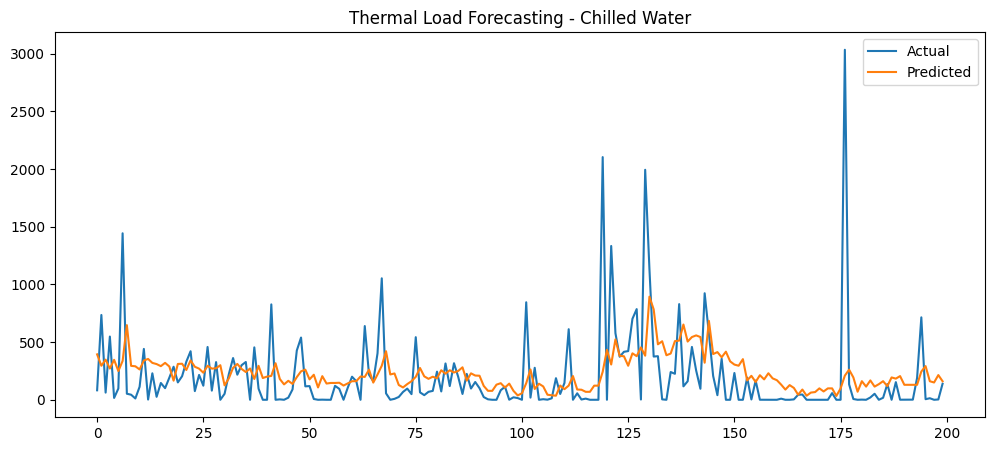

In [29]:
# Plot first 200 actual vs predicted values
plt.figure(figsize=(12, 5))
plt.plot(y_test.values[:200], label='Actual')
plt.plot(y_pred[:200], label='Predicted')
plt.title('Thermal Load Forecasting - Chilled Water')
plt.legend()
plt.savefig("result.png")
plt.show()

## Feature Importance

Feature importance helps identify which inputs had the strongest influence on the model’s predictions.

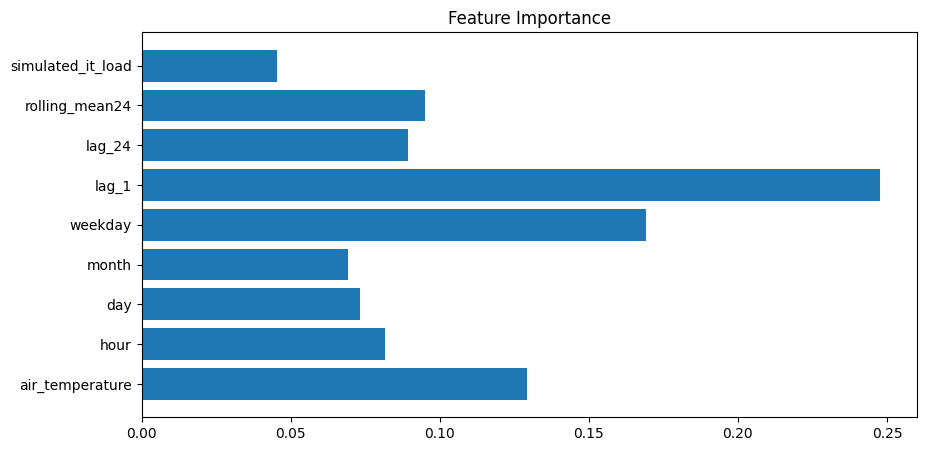

In [30]:
# Extract feature importance values from trained model
importances = model.feature_importances_

# Plot feature importance
plt.figure(figsize=(10, 5))
plt.barh(features, importances)
plt.title('Feature Importance')
plt.show()

## Conclusion

This project developed a time-series XGBoost model to forecast chilled water cooling demand.

Key takeaways:
- Chilled water readings were used as a cooling load / thermal load target
- Weather, time-based features, lag features, rolling averages, and simulated IT load were used as inputs
- The model captured the general cooling demand trend
- Sudden spikes were harder to predict, which is common in real-world load forecasting

This project demonstrates how machine learning can support data center thermal management and cooling demand forecasting.